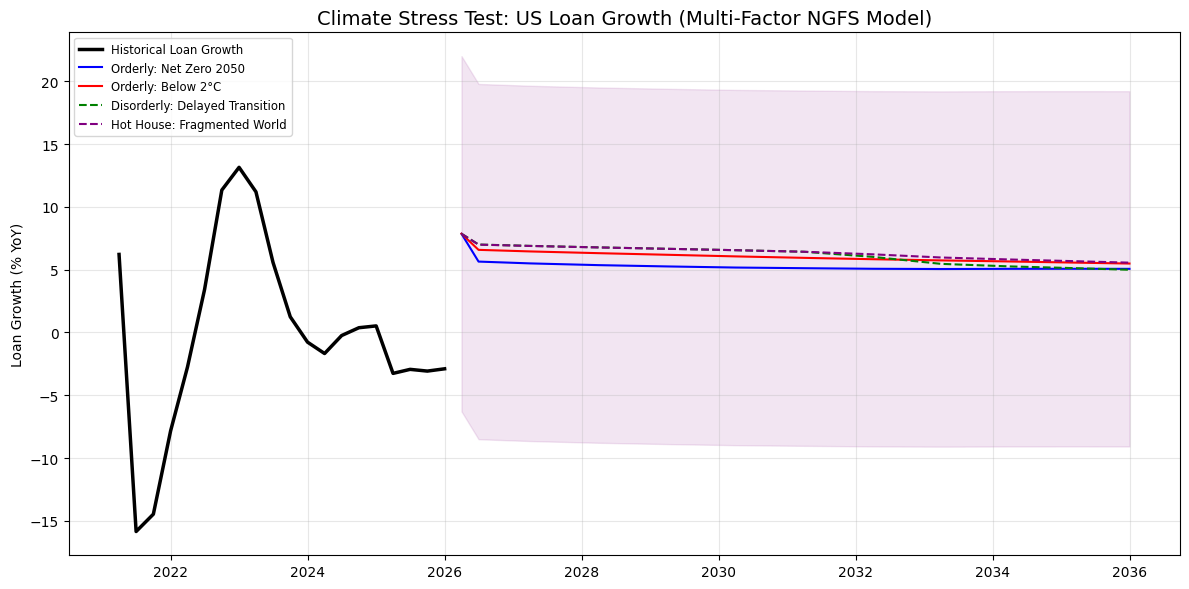

Model Summary:
                                SARIMAX Results                                
Dep. Variable:            Loan_Growth   No. Observations:                  281
Model:                          ARIMA   Log Likelihood                -954.115
Date:                Wed, 08 Apr 2026   AIC                           1918.230
Time:                        18:04:16   BIC                           1936.422
Sample:                    12-31-1955   HQIC                          1925.526
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                11.8774      1.841      6.451      0.000       8.269      15.486
Unemployment_Lag1    -1.1058      0.242     -4.560      0.000      -1.581      -0.631
GDP_Lag1

In [15]:
## MULTIMODAL FINAL MODEL

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. CLEAN FRED DATA
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception:
        return pd.DataFrame()

# Load ALL required data
df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
df_gdp = clean_fred_data('GDPC1.csv', 'GDP')
df_rates = clean_fred_data('FEDFUNDS.csv', 'Rates')

# ---------------------------------------------------------
# 2. MERGE + TARGET VARIABLE
# ---------------------------------------------------------
df_history = pd.concat([
    df_loans, df_unemp, df_gdp, df_rates
], axis=1).dropna()

df_history['Loan_Growth'] = np.log(df_history['Loans_Billions']).diff(4) * 100
df_history['GDP'] = np.log(df_history['GDP']).diff(4)*100 # log-transform GDP for better modeling

# ---------------------------------------------------------
# 3. DUMMY COVID
# ---------------------------------------------------------
df_history['COVID_Dummy'] = 0
shock_start, shock_end = '2020-03-01', '2021-06-30'
df_history.loc[shock_start:shock_end, 'COVID_Dummy'] = 1

# ---------------------------------------------------------
# 4. FEATURE ENGINEERING (CRITICAL UPGRADE)
# ---------------------------------------------------------
df_history['Unemployment_Lag1'] = df_history['Unemployment_Rate'].shift(1)
df_history['GDP_Lag1'] = df_history['GDP'].shift(1)
df_history['Rates_Lag1'] = df_history['Rates'].shift(1)


df_train = df_history.dropna()

# ---------------------------------------------------------
# 5. TRAIN MODEL (NOW ACTUALLY MULTI-FACTOR)
# ---------------------------------------------------------
y = df_train['Loan_Growth']

X = df_train[['Unemployment_Lag1', 'GDP_Lag1','COVID_Dummy']] # removed Rates_lag1



model = ARIMA(
    y,
    exog=X,
    order=(0, 0, 0),
    seasonal_order=(0, 0, 0, 4)
)

model_fit = model.fit()

# ---------------------------------------------------------
# 6. FORECAST SETUP
# ---------------------------------------------------------
forecast_steps = 40 # 10 years of quarterly forecasts
last_hist_date = df_history.index[-1]

forecast_dates = pd.date_range(
    start=last_hist_date,
    periods=forecast_steps + 1,
    freq='QE'
)[1:]

last_unemp = df_history['Unemployment_Rate'].iloc[-1]
last_gdp = df_history['GDP'].iloc[-1]
last_rates = df_history['Rates'].iloc[-1]

# ---------------------------------------------------------
# 7. NGFS HELPER
# ---------------------------------------------------------
def get_ngfs_series(scenario, keyword):
    cols = [c for c in ngfs_quarterly.columns if scenario in c and keyword in c]
    if len(cols) == 0:
        raise ValueError(f"{keyword} not found for {scenario}")
    return ngfs_quarterly[cols[0]]

# ---------------------------------------------------------
# 8. BUILD MULTI-FACTOR EXOG 
# ---------------------------------------------------------
def build_ngfs_exog_multi(scenario):
    # 1. Pull the Shocks from your NGFS DataFrame
    unemp_shock = get_ngfs_series(scenario, "Unemployment")
    gdp_shock_pct = get_ngfs_series(scenario, "Gross Domestic Product")
    rate_shock = get_ngfs_series(scenario, "Central bank")

    # 2. Slice to the forecast horizon (40 quarters)
    u_s = unemp_shock.loc[forecast_dates[0]:].head(forecast_steps)
    g_s = gdp_shock_pct.loc[forecast_dates[0]:].head(forecast_steps)
    r_s = rate_shock.loc[forecast_dates[0]:].head(forecast_steps)

    # 3. Apply the Hybrid FRED-NiGEM Logic
    # (Shock + Last FRED Actual)
    unemp_future = last_unemp + u_s.values
    rate_future = last_rates + r_s.values
    # (Percentage Shock * Last FRED Actual)
    gdp_future = last_gdp + g_s.values # this assumes the shock is in percentage points, adjust if it's a multiplier

    # 4. Concatenate for Lagging
    future_df = pd.DataFrame({
        'Unemployment_Rate': unemp_future,
        'GDP': gdp_future
    }, index=forecast_dates) # removed 'Rates': rate_future

    full_series = pd.concat([df_history[['Unemployment_Rate','GDP','Rates']], future_df])

    # 5. SYMMETRIC FEATURES: Ensure shift(1) matches the training model
    X_f = pd.DataFrame(index=forecast_dates)
    X_f['Unemployment_Lag1'] = full_series['Unemployment_Rate'].shift(1).loc[forecast_dates]
    X_f['GDP_Lag1'] = full_series['GDP'].shift(1).loc[forecast_dates]
    X_f['COVID_Dummy'] = 0 # No COVID shock in the future
    #X_f['Rates_Lag1'] = full_series['Rates'].shift(1).loc[forecast_dates]
    
    return X_f

# ---------------------------------------------------------
# 9. RUN ALL SCENARIOS
# ---------------------------------------------------------
scenarios = {
    "Net Zero 2050": "Orderly: Net Zero 2050",
    "Below 2°C": "Orderly: Below 2°C",
    "Delayed transition": "Disorderly: Delayed Transition",
    "Fragmented World": "Hot House: Fragmented World"
}

results = {}

for key in scenarios:
    X_future = build_ngfs_exog_multi(key)
    results[key] = model_fit.get_forecast(steps=forecast_steps, exog=X_future)

# ---------------------------------------------------------
# 10. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    df_train.index[-20:],
    df_train['Loan_Growth'][-20:],
    label='Historical Loan Growth',
    color='black',
    linewidth=2.5
)

colors = {
    "Net Zero 2050": "blue",
    "Below 2°C": "red",
    "Delayed transition": "green",
    "Fragmented World": "purple"
}

linestyles = {
    "Net Zero 2050": "-",
    "Below 2°C": "-",
    "Delayed transition": "--",
    "Fragmented World": "--"
}

for key in results:
    plt.plot(
        forecast_dates,
        results[key].predicted_mean,
        label=scenarios[key],
        color=colors[key],
        linestyle=linestyles[key]
    )

# Confidence interval (worst case)
conf = results["Net Zero 2050"].conf_int()
plt.fill_between(
    forecast_dates,
    conf.iloc[:, 0],
    conf.iloc[:, 1],
    color='purple',
    alpha=0.1
)

plt.title('Climate Stress Test: US Loan Growth (Multi-Factor NGFS Model)', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Results
print("Model Summary:\n", model_fit.summary())

In [2]:
# -----------------------------
# 1️⃣ Load NGFS NiGEM Excel
# -----------------------------
ngfs_file = "NiGEM_data.xlsx"
ngfs = pd.read_excel(ngfs_file)

# -----------------------------
# 2️⃣ Filter for US & relevant variables
# -----------------------------
ngfs_us = ngfs[ngfs['Region'] == 'NiGEM NGFS v1.24.2|United States']
ngfs_us = ngfs_us[ngfs_us['Variable'].str.contains('combined', case=False, na=False)]

# -----------------------------
# 3️⃣ Melt annual columns into long format
# -----------------------------
year_cols = [c for c in ngfs_us.columns if c.isdigit()]
ngfs_long = ngfs_us.melt(id_vars=['Model','Scenario','Region','Variable','Unit'], 
                         value_vars=year_cols,
                         var_name='Year', value_name='Value')

# Convert Year to datetime
ngfs_long['Year'] = pd.to_datetime(ngfs_long['Year'].astype(str) + '-12-31')

# -----------------------------
# 4️⃣ Pivot: Scenario + Variable as columns
# -----------------------------
ngfs_pivot = ngfs_long.pivot_table(index='Year', 
                                   columns=['Scenario','Variable'], 
                                   values='Value')

# Optional: flatten column MultiIndex
ngfs_pivot.columns = [f"{sc}_{var}" for sc, var in ngfs_pivot.columns]

# -----------------------------
# 5️⃣ Interpolate to quarterly
# -----------------------------
ngfs_quarterly = ngfs_pivot.resample('QE').interpolate(method='linear') 

# Quick check
print(ngfs_quarterly.head(10))
print("\nColumns:", ngfs_quarterly.columns.tolist())

            Below 2°C_Carbon pricing ; $ per Tn CO2(combined)  \
Year                                                            
2022-12-31                                           0.000000   
2023-03-31                                           1.908148   
2023-06-30                                           3.816295   
2023-09-30                                           5.724443   
2023-12-31                                           7.632591   
2024-03-31                                           8.359504   
2024-06-30                                           9.086418   
2024-09-30                                           9.813331   
2024-12-31                                          10.540245   
2025-03-31                                          11.267158   

            Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined)  \
Year                                                                                        
2022-12-31                       